# Dataset Comparison

Comprehensive comparison of all raw datasets across size, feature coverage, data quality, and PricePilot relevance.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Find project root dynamically - works on any machine after cloning
notebook_dir = Path.cwd()
if 'eda' not in str(notebook_dir):
    notebook_dir = Path.cwd().parents[0]
project_root = notebook_dir.parents[0] if (notebook_dir / 'notebooks').exists() else notebook_dir.parents[1]
report_dir = project_root / 'eda' / 'reports'

# Load inventory
inventory_path = report_dir / 'dataset_inventory_summary.csv'
inventory = pd.read_csv(inventory_path)
print("Dataset Inventory")
print(f"Total datasets: {len(inventory)}")
display(inventory)


Dataset Inventory
Total datasets: 9


,file_name,file_format,rows,columns,date_columns,price_columns,sales_columns,identifier_columns,potential_role
0,catalog.csv,csv,219810,8,NaN,NaN,NaN,item_id,Catalog / metadata / reference
1,discounts_history.csv,csv,35202,3,date,NaN,NaN,"item_id, store_id",Retail pricing / demand / promotion analytics
2,ecommerce_sales_34500.csv,csv,7432685,6,date,price_base,"quantity, sum_total","item_id, store_id",Retail pricing / demand / promotion analytics
3,markdowns.csv,csv,2800,10,date,price,units_sold,"store_id, product_id",Retail pricing / demand / promotion analytics
4,online.csv,csv,698626,5,date,price,NaN,"item_id, store_id",Ecommerce revenue / pricing / customer behavior
5,price_history.csv,csv,8979,6,date,"normal_price, price",quantity,"item_id, store_id",Retail pricing / demand / promotion analytics
6,retail_store_sales_promotions_demand.csv,csv,1123412,6,date,price_base,"quantity, sum_total","item_id, store_id",Retail pricing / demand / promotion analytics
7,sales.csv,csv,3746744,8,"date, sale_price_time_promo","sale_price_before_promo, sale_price_time_promo",NaN,"item_id, doc_id, store_id",Retail pricing / demand / promotion analytics
8,stores.csv,csv,4,5,NaN,NaN,NaN,store_id,Catalog / metadata / reference


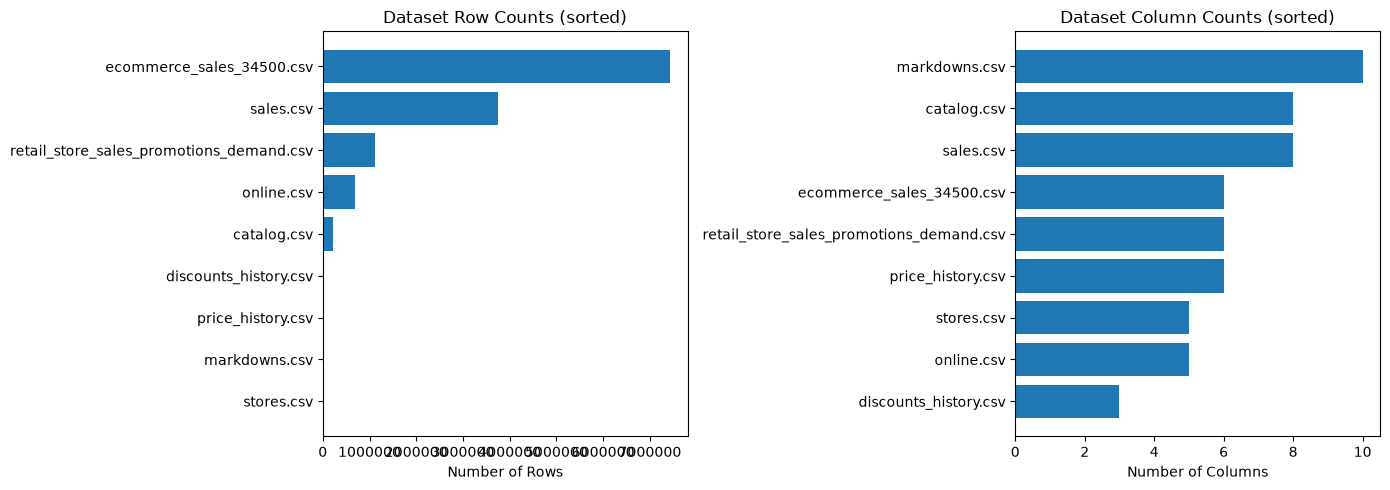

In [2]:

# Dataset dimensions comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Row counts
inv_sorted = inventory.sort_values('rows', ascending=True)
axes[0].barh(inv_sorted['file_name'], inv_sorted['rows'])
axes[0].set_xlabel('Number of Rows')
axes[0].set_title('Dataset Row Counts (sorted)')
axes[0].ticklabel_format(style='plain', axis='x')

# Column counts
inv_sorted_cols = inventory.sort_values('columns', ascending=True)
axes[1].barh(inv_sorted_cols['file_name'], inv_sorted_cols['columns'])
axes[1].set_xlabel('Number of Columns')
axes[1].set_title('Dataset Column Counts (sorted)')

plt.tight_layout()
plt.show()


In [3]:

# Feature coverage analysis
features_df = pd.DataFrame({
    'Dataset': inventory['file_name'],
    'Has Price': inventory['price_columns'].notna() & (inventory['price_columns'] != ''),
    'Has Sales/Qty': inventory['sales_columns'].notna() & (inventory['sales_columns'] != ''),
    'Has Date': inventory['date_columns'].notna() & (inventory['date_columns'] != ''),
    'Has Identifiers': inventory['identifier_columns'].notna() & (inventory['identifier_columns'] != ''),
})

print("PricePilot Feature Coverage by Dataset")
display(features_df)

# Coverage percentage
coverage_cols = ['Has Price', 'Has Sales/Qty', 'Has Date', 'Has Identifiers']
features_df['Feature Coverage %'] = (features_df[coverage_cols].sum(axis=1) / len(coverage_cols) * 100).round(1)
display(features_df[['Dataset', 'Feature Coverage %']])


PricePilot Feature Coverage by Dataset


,Dataset,Has Price,Has Sales/Qty,Has Date,Has Identifiers
0,catalog.csv,False,False,False,True
1,discounts_history.csv,False,False,True,True
2,ecommerce_sales_34500.csv,True,True,True,True
3,markdowns.csv,True,True,True,True
4,online.csv,True,False,True,True
5,price_history.csv,True,True,True,True
6,retail_store_sales_promotions_demand.csv,True,True,True,True
7,sales.csv,True,False,True,True
8,stores.csv,False,False,False,True


,Dataset,Feature Coverage %
0,catalog.csv,25.0
1,discounts_history.csv,50.0
2,ecommerce_sales_34500.csv,100.0
3,markdowns.csv,100.0
4,online.csv,75.0
5,price_history.csv,100.0
6,retail_store_sales_promotions_demand.csv,100.0
7,sales.csv,75.0
8,stores.csv,25.0


In [4]:

# Dataset categorization
retail_keywords = ['sales', 'markdown', 'discount', 'price', 'actual', 'demand', 'promotions']
ecommerce_keywords = ['amazon', 'ecommerce', 'online']
reference_keywords = ['catalog', 'stores', 'product']

categories = []
for idx, row in inventory.iterrows():
    name = row['file_name'].lower()
    if any(k in name for k in retail_keywords):
        cat = 'Retail Analytics'
    elif any(k in name for k in ecommerce_keywords):
        cat = 'Ecommerce Analytics'
    else:
        cat = 'Reference/Metadata'
    categories.append(cat)

inventory['Category'] = categories

print("Datasets by Category")
category_summary = inventory.groupby('Category')[['rows', 'columns']].agg({'rows': 'sum', 'columns': 'mean'})
display(category_summary)

print("\nDetailed Classification")
for cat in inventory['Category'].unique():
    print(f"\n{cat}:")
    for f in inventory[inventory['Category'] == cat]['file_name']:
        print(f"  - {f}")


Datasets by Category


,rows,columns
Category,,
Ecommerce Analytics,698626,5.0
Reference/Metadata,219814,6.5
Retail Analytics,12349822,6.5



Detailed Classification

Reference/Metadata:
  - catalog.csv
  - stores.csv

Retail Analytics:
  - discounts_history.csv
  - ecommerce_sales_34500.csv
  - markdowns.csv
  - price_history.csv
  - retail_store_sales_promotions_demand.csv
  - sales.csv

Ecommerce Analytics:
  - online.csv


In [5]:

# Data quality indicators
print("Data Quality Summary")
print("\nNote: Data quality is assessed during individual dataset EDA.")
print("Review the individual dataset reports for:")
print("- Missing value percentages")
print("- Duplicate row detection")
print("- Date range and temporal coverage")
print("- Outlier analysis")
print("\nReports location: eda/reports/")


Data Quality Summary

Note: Data quality is assessed during individual dataset EDA.
Review the individual dataset reports for:
- Missing value percentages
- Duplicate row detection
- Date range and temporal coverage
- Outlier analysis

Reports location: eda/reports/


In [6]:

# Dataset integration readiness analysis
print("Dataset Integration Readiness Assessment")
print("\nBefore merging datasets, analyze:")
print("1. Common key fields (product_id, store_id, date, etc.)")
print("2. Data granularity alignment (transaction vs. summary level)")
print("3. Temporal overlap between datasets")
print("4. Data type consistency")
print("5. Potential duplicate keys")
print("\nNote: Individual dataset reports include key field analysis.")
print("Cross-dataset integration is documented in individual report recommendations.")


Dataset Integration Readiness Assessment

Before merging datasets, analyze:
1. Common key fields (product_id, store_id, date, etc.)
2. Data granularity alignment (transaction vs. summary level)
3. Temporal overlap between datasets
4. Data type consistency
5. Potential duplicate keys

Note: Individual dataset reports include key field analysis.
Cross-dataset integration is documented in individual report recommendations.


In [7]:

# Recommendations for PricePilot
print("RECOMMENDATIONS FOR PRICEPILOT PROJECT")
print("=" * 60)
print("\nPRIMARY DATASETS (Most relevant for pricing):")
for idx, row in inventory[inventory['potential_role'].str.contains('Retail')].iterrows():
    print(f"  ✓ {row['file_name']}")
    print(f"    Rows: {row['rows']:,} | Columns: {row['columns']}")
    print(f"    Features: {row['price_columns'] if pd.notna(row['price_columns']) else 'None'}")

print("\nSUPPORTING DATASETS (Context/metadata):")
for idx, row in inventory[~inventory['potential_role'].str.contains('Retail|Ecommerce')].iterrows():
    print(f"  • {row['file_name']}")
    print(f"    Rows: {row['rows']:,} | Columns: {row['columns']}")

print("\nECOMMERCE DATASETS (Alternative/parallel analysis):")
for idx, row in inventory[inventory['potential_role'].str.contains('Ecommerce')].iterrows():
    print(f"  ◦ {row['file_name']}")
    print(f"    Rows: {row['rows']:,} | Columns: {row['columns']}")

print("\nNEXT STEPS:")
print("  1. Review individual dataset EDA reports in eda/reports/")
print("  2. Validate temporal consistency across datasets")
print("  3. Analyze key field uniqueness and overlap")
print("  4. Assess data leakage risks (see leakage_audit_report.csv)")
print("  5. Plan dataset integration strategy based on business requirements")


RECOMMENDATIONS FOR PRICEPILOT PROJECT

PRIMARY DATASETS (Most relevant for pricing):
  ✓ discounts_history.csv
    Rows: 35,202 | Columns: 3
    Features: None
  ✓ ecommerce_sales_34500.csv
    Rows: 7,432,685 | Columns: 6
    Features: price_base
  ✓ markdowns.csv
    Rows: 2,800 | Columns: 10
    Features: price
  ✓ price_history.csv
    Rows: 8,979 | Columns: 6
    Features: normal_price, price
  ✓ retail_store_sales_promotions_demand.csv
    Rows: 1,123,412 | Columns: 6
    Features: price_base
  ✓ sales.csv
    Rows: 3,746,744 | Columns: 8
    Features: sale_price_before_promo, sale_price_time_promo

SUPPORTING DATASETS (Context/metadata):
  • catalog.csv
    Rows: 219,810 | Columns: 8
  • stores.csv
    Rows: 4 | Columns: 5

ECOMMERCE DATASETS (Alternative/parallel analysis):
  ◦ online.csv
    Rows: 698,626 | Columns: 5

NEXT STEPS:
  1. Review individual dataset EDA reports in eda/reports/
  2. Validate temporal consistency across datasets
  3. Analyze key field uniqueness and